# ТУТОРИАЛ: SVM ДЛЯ КЛАССИФИКАЦИИ ДАННЫХ

## Часть 0: настройка окружения

In [17]:
# установка необходимых библиотек
!pip install numpy pandas matplotlib seaborn scikit-learn

# импорт
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

---

## Часть 1: загрузка и знакомство с данными

In [3]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("размер данных:", X.shape)
print("количество классов:", len(np.unique(y)))
print("названия классов:", target_names)
print("признаки:", feature_names)

размер данных: (150, 4)
количество классов: 3
названия классов: ['setosa' 'versicolor' 'virginica']
признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## Часть 2: изучение данных с графиками

In [4]:
# создаем DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({0: target_names[0], 1: target_names[1], 2: target_names[2]})
# первые 5 строк
print(df.head())

# базовая статистика
print(df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%            

/tmp/ipython-input-4226153052.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='Set2')


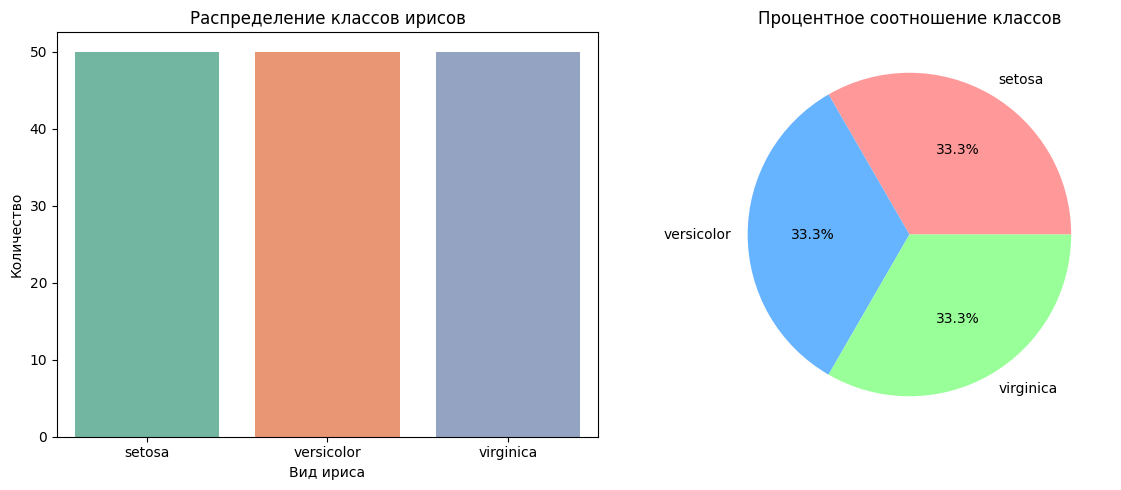

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='species', data=df, palette='Set2')
plt.title('Распределение классов ирисов')
plt.xlabel('Вид ириса')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
class_counts = df['target'].value_counts()
plt.pie(class_counts, labels=target_names, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Процентное соотношение классов')
plt.tight_layout()
plt.show()

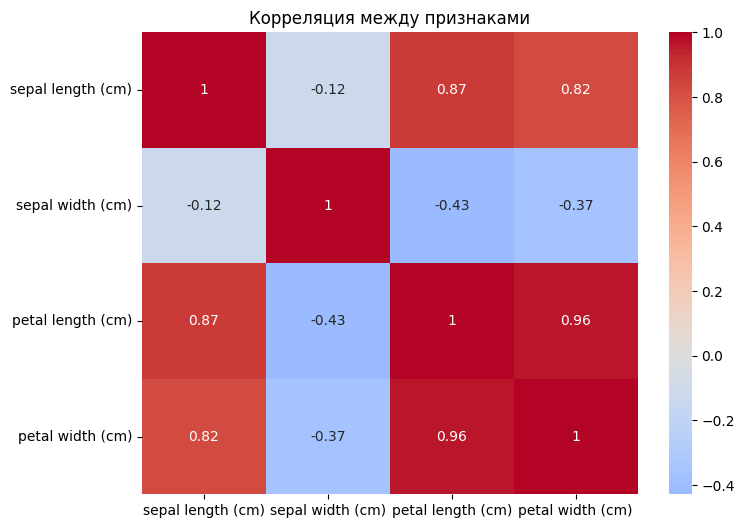

In [6]:
# Корреляционная матрица
plt.figure(figsize=(8, 6))
corr_matrix = df[feature_names].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция между признаками')
plt.show()

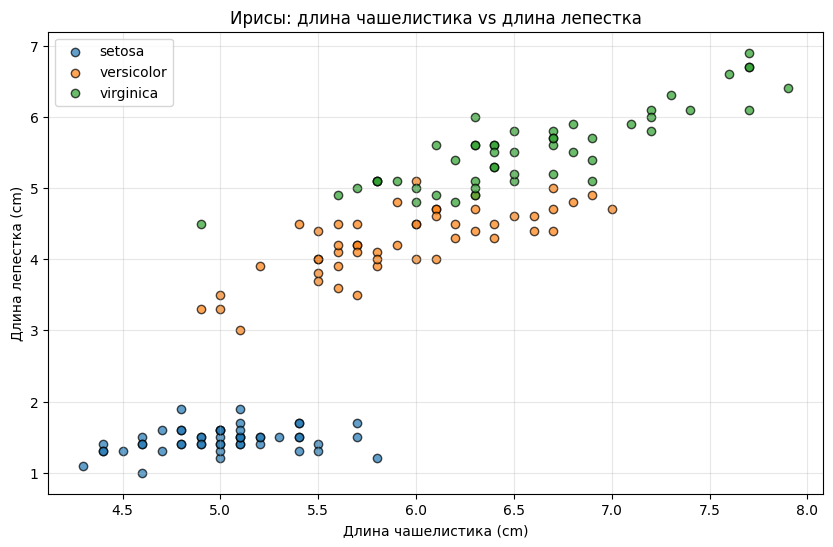

In [7]:
# Визуализация в 2D: выберем два признака – длина чашелистика и длина лепестка

plt.figure(figsize=(10, 6))
for i, species in enumerate(target_names):
    subset = df[df['target'] == i]
    plt.scatter(subset['sepal length (cm)'], subset['petal length (cm)'],
                label=species, alpha=0.7, edgecolors='k')
plt.xlabel('Длина чашелистика (cm)')
plt.ylabel('Длина лепестка (cm)')
plt.title('Ирисы: длина чашелистика vs длина лепестка')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Часть 3: математические основы SVM

### 3.1 что такое SVM? понимание через аналогии

**SVM (Support Vector Machine, метод опорных векторов)** — это алгоритм, который находит **оптимальную границу** между классами.

**Представьте:**
- у вас есть два типа шариков на столе: красные и синие
- вы хотите провести линию, которая их разделяет
- таких линий можно провести бесконечно много
- SVM выбирает **линию с максимальным запасом** от ближайших шариков каждой группы

### 3.2 ключевые компоненты SVM

#### **Support vectors (опорные векторы)**
- это самые "сложные" точки данных — те, которые находятся ближе всего к разделяющей границе
- именно они "поддерживают" (support) границу
- если убрать все остальные точки, граница останется прежней
- в реальности: пациенты с пограничными анализами, отзывы с неявной тональностью

#### **Margin (зазор)**
- расстояние от разделяющей линии до ближайших точек каждого класса
- чем больше зазор — тем устойчивее модель к шуму в данных
- SVM специально **максимизирует этот зазор** (maximum margin classifier)

#### **Hyperplane (гиперплоскость)**
- в 2D: линия (y = kx + b)
- в 3D: плоскость
- в n-мерном пространстве: (n-1)-мерная "плоскость", разделяющая пространство
- математически: w₁x₁ + w₂x₂ + ... + wₙxₙ + b = 0

### 3.3 как SVM работает в многомерных пространствах?

**Проблема:** в реальных данных признаки могут быть неразделимы прямой линией в исходном пространстве.

**Решение SVM: ядерный трюк (kernel trick)**

1. **Неявное преобразование:** данные переводятся в пространство более высокой размерности
2. **Магия вычислений:** SVM вычисляет скалярные произведения в новом пространстве, не вычисляя само преобразование
3. **Результат:** в новом пространстве данные становятся линейно разделимыми

**Пример:** представьте, что у вас есть круг красных точек внутри кольца синих. В 2D их нельзя разделить прямой, но если добавить третье измерение (расстояние от центра), они становятся разделимыми плоскостью.

### 3.4 основные типы ядер (kernels)

**Ядро** — функция, которая позволяет SVM работать с нелинейно разделимыми данными:

- **Линейное ядро:** для линейно разделимых данных (самый простой случай)
- **Полиномиальное ядро:** добавляет полиномиальные комбинации признаков
- **RBF (радиально-базисное ядро):** наиболее популярное, создает сложные нелинейные границы
- **Сигмоидное ядро:** похоже на нейронную сеть

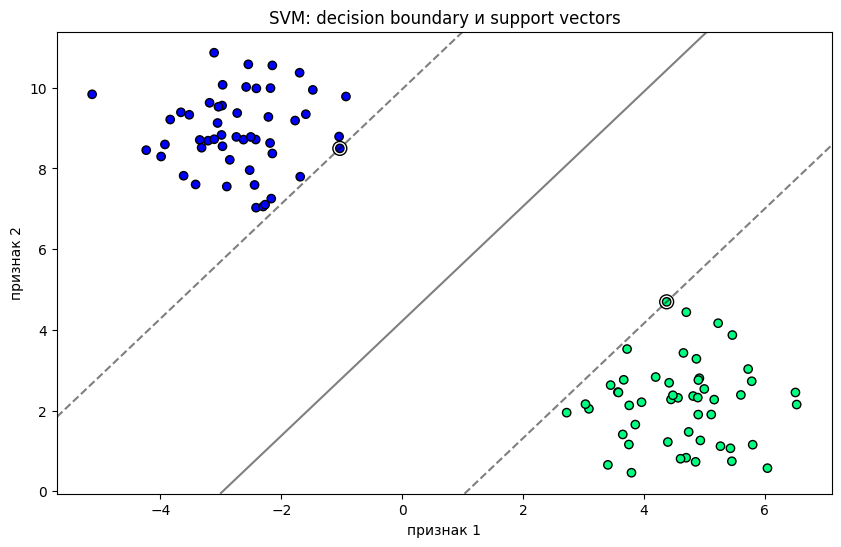

In [8]:
# визуализация для понимания
from sklearn.datasets import make_blobs

# создаем искусственные данные
X_visual, y_visual = make_blobs(n_samples=100, centers=2, random_state=42)

# обучаем SVM
svm_visual = SVC(kernel='linear')
svm_visual.fit(X_visual, y_visual)

# функция для визуализации SVM
def plot_svm_boundary(model, X, y):
    plt.figure(figsize=(10, 6))

    # точки данных
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')

    # decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # сетка для построения границы
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # граница и margin
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # support vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=100, linewidth=1, facecolors='none', edgecolors='k')

    plt.xlabel('признак 1')
    plt.ylabel('признак 2')
    plt.title('SVM: decision boundary и support vectors')
    plt.show()

plot_svm_boundary(svm_visual, X_visual, y_visual)

## Часть 4: подготовка данных для SVM

In [9]:
# разделяем данные (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size: {X_train.shape}")
print(f"test size: {X_test.shape}")
print(f"train class distribution: {np.bincount(y_train)}")
print(f"test class distribution: {np.bincount(y_test)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nРазмер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)
print("Распределение классов в обучении:", np.bincount(y_train))
print("Распределение классов в тесте:", np.bincount(y_test))

train size: (120, 4)
test size: (30, 4)
train class distribution: [40 40 40]
test class distribution: [10 10 10]

Размер обучающей выборки: (105, 4)
Размер тестовой выборки: (45, 4)
Распределение классов в обучении: [35 35 35]
Распределение классов в тесте: [15 15 15]


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nПример до масштабирования (первые 3 признака):", X_train[0, :3])
print("Пример после масштабирования:", X_train_scaled[0, :3])


Пример до масштабирования (первые 3 признака): [5.1 2.5 3. ]
Пример после масштабирования: [-0.90045861 -1.22024754 -0.4419858 ]


## Часть 5: обучение SVM

In [11]:
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"\nЛинейный SVM accuracy: {accuracy_linear:.2%}")
print("\nClassification report (линейный):")
print(classification_report(y_test, y_pred_linear, target_names=target_names))


Линейный SVM accuracy: 91.11%

Classification report (линейный):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



## Часть 6: меняем и переобучаем

In [12]:
C_values = [0.1, 1, 10]
accuracies = {}
for C in C_values:
    svm_temp = SVC(kernel='linear', C=C, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc = svm_temp.score(X_test_scaled, y_test)
    accuracies[C] = acc
    print(f"C={C}: accuracy = {acc:.2%}")

# Выбираем лучшее C
best_C = max(accuracies, key=accuracies.get)
print(f"\nЛучшее значение C: {best_C} с accuracy {accuracies[best_C]:.2%}")

# Обучаем лучшую модель (для единообразия используем best_C)
best_svm = SVC(kernel='linear', C=best_C, random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred_best = best_svm.predict(X_test_scaled)

C=0.1: accuracy = 91.11%
C=1: accuracy = 91.11%
C=10: accuracy = 91.11%

Лучшее значение C: 0.1 с accuracy 91.11%


## Часть 7: матрица ошибок и метрики

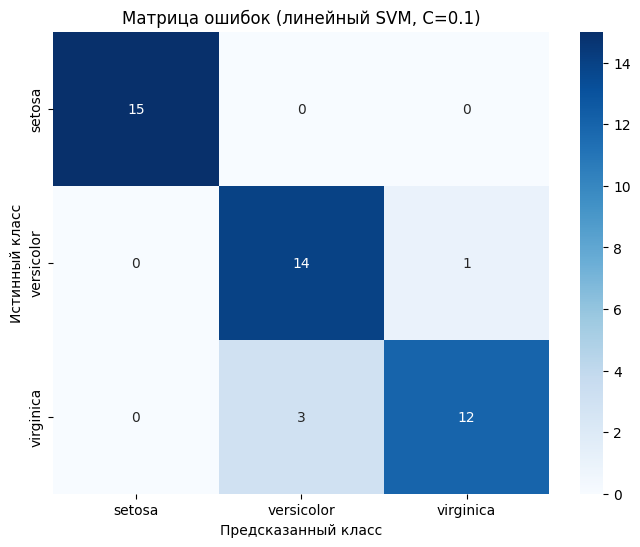

In [13]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок (линейный SVM, C={best_C})')
plt.show()

In [18]:
print("\nДетальный отчет по классификации (лучшая модель):")
print(classification_report(y_test, y_pred_best, target_names=target_names))

# Вычисляем метрики вручную (weighted average)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"\nИтоговые метрики (weighted):")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")


Детальный отчет по классификации (лучшая модель):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45


Итоговые метрики (weighted):
Precision: 91.55%
Recall:    91.11%
F1-score:  91.07%


## Часть 8: анализ ошибок

In [19]:
error_indices = np.where(y_pred_best != y_test)[0]
print(f"\nКоличество ошибок: {len(error_indices)}")

if len(error_indices) > 0:
    print("\nПримеры ошибок (до 2):")
    for i, idx in enumerate(error_indices[:2]):
        print(f"\nОшибка {i+1}:")
        print(f"  Истинный класс: {target_names[y_test[idx]]}")
        print(f"  Предсказанный:  {target_names[y_pred_best[idx]]}")
        print(f"  Значения признаков (масштабированные): {X_test_scaled[idx]}")
else:
    print("Ошибок нет – идеальная классификация!")


Количество ошибок: 4

Примеры ошибок (до 2):

Ошибка 1:
  Истинный класс: virginica
  Предсказанный:  versicolor
  Значения признаков (масштабированные): [ 0.49680475 -0.56093712  0.74075533  0.38029394]

Ошибка 2:
  Истинный класс: virginica
  Предсказанный:  versicolor
  Значения признаков (масштабированные): [ 0.26392752 -1.0004774   1.02236036  0.25106784]


In [20]:
print(f"количество support vectors: {len(best_svm.support_vectors_)}")
print(f"количество support vectors по классам: {best_svm.n_support_}")
print(f"процент точек, являющихся support vectors: {len(best_svm.support_vectors_)/len(X_train):.1%}")

количество support vectors: 54
количество support vectors по классам: [ 8 26 20]
процент точек, являющихся support vectors: 51.4%


---

## Часть 9: график обучения (learning curve)

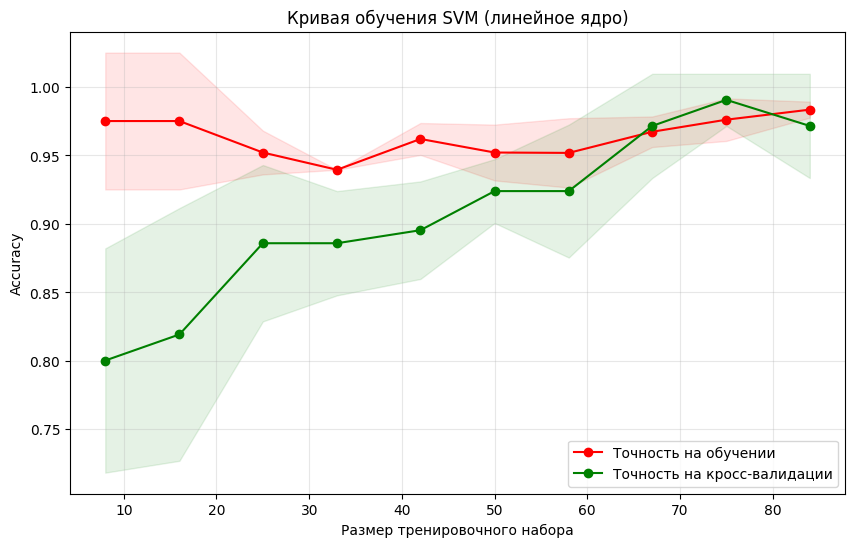

In [21]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_svm, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Точность на обучении')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Точность на кросс-валидации')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Размер тренировочного набора')
plt.ylabel('Accuracy')
plt.title('Кривая обучения SVM (линейное ядро)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

In [24]:
# Какая точность достигнута?

print(f"Лучшая модель достигла точности {accuracies[best_C]:.2%} на тестовой выборке при C={best_C}.")

Лучшая модель достигла точности 91.11% на тестовой выборке при C=0.1.


# Какая точность достигнута?
Лучшая модель достигла точности 91.11% на тестовой выборке при C=0.1.

# На каких классах чаще ошибается модель?

Ошибки возникают между классами versicolor и virginica. Из 4 ошибок все относятся к случаям, когда истинный класс virginica был предсказан как versicolor. Класс setosa классифицируется безошибочно (precision/recall = 1.00).

# Какие параметры SVM сработали лучше всего?

Использовалось линейное ядро. Все три значения C (0.1, 1, 10) показали одинаковую точность, поэтому лучшим формально выбран C = 0.1. Количество опорных векторов составило 54 (около 51% обучающих данных), что указывает на относительно сложную границу даже при линейном разделении.

# Модель переобучается или недообучается?
Модель не демонстрирует явного переобучения или недообучения: кривая обучения показывает небольшой разрыв между тренировочной и валидационной точностью, обе стремятся к значениям около 91–95%, что свидетельствует о хорошем обобщении.

# Что можно улучшить:

Использовать нелинейное ядро (например, RBF) для более гибкого разделения классов versicolor и virginica, между которыми наблюдаются основные ошибки.

Провести подбор гиперпараметров (C и gamma) с помощью кросс-валидации (GridSearchCV), чтобы найти оптимальные значения.

Добавить синтетические признаки (например, полиномиальные) или использовать методы понижения размерности для лучшей визуализации и разделения.